<a href="https://colab.research.google.com/github/Midas5665/DetectareSER/blob/main/DetectareSER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing packages and files

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
import umap
import umap.umap_ as umap_module
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_selection import RFE

In [3]:
from google.colab import files
uploaded = files.upload()

Saving dateSVM220426.csv to dateSVM220426.csv


In [4]:
data = pd.read_csv("dateSVM220426.csv", engine = "python", thousands = ",", sep=";");

In [5]:
data.head(10)

,Spectrum_1,Class,"32,731245","36,921835","41,108991","45,292716","49,473015","53,649892","57,82335","61,993394",...,"2977,934027","2979,970992","2982,00663","2984,040943","2986,073932","2988,105598","2990,135942","2992,164965","2994,192668","2996,219053"
0,E8 dupa 2h RT ser cu 1 ug mL MMP9 dil 50 x tp...,ser cu MMP9,-1.405545e+09,-1.280555e+09,-1.156355e+09,-1.031772e+09,-9.075437e+09,-7.849240e+09,-6.620466e+09,-5.397758e+09,...,-8.048682e+09,-8.535718e+09,-9.062075e+09,-9.602381e+09,-1.021383e+09,-6.593349e+09,-3.154772e+09,1.700752e+09,-8.176698e+09,-1.798261e+09
1,E9 dupa 2h RT ser cu 1 ug mL MMP9 dil 50 x tp...,ser cu MMP9,-1.350225e+09,-1.230132e+09,-1.110663e+09,-9.907451e+09,-8.721887e+09,-7.536740e+09,-6.360457e+09,-5.185659e+09,...,-8.149744e+09,-8.607685e+09,-9.154859e+09,-9.625506e+09,-1.023401e+09,-6.623837e+09,-3.175427e+09,1.659800e+09,-7.784614e+09,-1.742499e+09
2,E10 dupa 2h RT ser cu 1 ug mL MMP9 dil 50 x t...,ser cu MMP9,-1.477319e+09,-1.346202e+09,-1.215673e+09,-1.084859e+09,-9.551318e+09,-8.249667e+09,-6.954705e+08,-5.654647e+09,...,-8.864836e+09,-9.403109e+09,-9.861288e+09,-1.044457e+09,-1.102944e+09,-7.148830e+09,-3.407001e+08,1.874901e+09,-8.415597e+09,-1.873486e+09
3,E11 dupa 2h RT ser cu 1 ug mL MMP9 dil 50 x t...,ser cu MMP9,-1.359744e+09,-1.238490e+09,-1.118160e+09,-9.977494e+09,-8.778637e+08,-7.592226e+09,-6.401291e+09,-5.220852e+09,...,-8.312597e+09,-8.791654e+09,-9.276463e+09,-9.755055e+09,-1.027128e+09,-6.632403e+09,-3.198803e+09,1.678950e+09,-7.679719e+09,-1.710061e+09
4,E12 dupa 2h RT ser cu 1 ug mL MMP9 dil 50 x t...,ser cu MMP9,-1.297824e+09,-1.182557e+09,-1.067747e+09,-9.528579e+09,-8.377950e+09,-7.238151e+09,-6.094914e+08,-4.961948e+09,...,-7.998567e+09,-8.510764e+09,-9.028366e+09,-9.589614e+09,-1.008794e+09,-6.507896e+09,-3.096220e+09,1.616796e+09,-7.592734e+09,-1.686448e+07
5,E13 dupa 2h RT ser dil 50 x tp cu BSA.exp ...,ser,-1.370769e+09,-1.248835e+09,-1.127390e+09,-1.006231e+09,-8.845939e+09,-7.642003e+09,-6.438879e+09,-5.238875e+09,...,-8.719890e+09,-9.287548e+09,-9.855124e+08,-1.045733e+09,-1.109775e+09,-7.205699e+09,-3.442321e+09,1.837881e+09,-8.805150e+09,-1.924287e+09
6,E14 dupa 2h RT ser dil 50 x tp cu BSA.exp ...,ser,-1.208203e+08,-1.099102e+09,-9.901254e+09,-8.820750e+09,-7.741235e+09,-6.665278e+09,-5.590686e+09,-4.513825e+09,...,-2.956400e+09,-3.167993e+09,-3.531285e+09,-3.831013e+09,-4.118351e+09,-2.628663e+07,-1.202164e+09,8.135280e+09,-4.468602e+09,-9.946771e+09
7,E16 dupa 2h RT ser dil 50 x tp cu BSA.exp ...,ser,-1.322717e+09,-1.204863e+09,-1.087567e+09,-9.707255e+09,-8.534416e+09,-7.368373e+09,-6.198189e+09,-5.034556e+09,...,-8.590656e+09,-9.134612e+08,-9.624525e+09,-1.027907e+09,-1.078427e+09,-7.014216e+09,-3.309147e+08,1.751434e+09,-7.969310e+09,-1.735102e+09
8,E18 dupa 2h RT ser dil 50 x tp cu BSA.exp ...,ser,-1.233010e+09,-1.122959e+09,-1.012897e+09,-9.025238e+09,-7.923150e+09,-6.829945e+09,-5.744424e+09,-4.651906e+09,...,-7.518431e+09,-7.869108e+09,-8.425505e+09,-8.904917e+09,-9.508429e+08,-6.147078e+09,-2.927233e+09,1.556107e+09,-7.297559e+08,-1.621345e+09
9,E19 2h RT ser dil 50 x tp BSA.exp ...,ser,-1.353106e+09,-1.233325e+09,-1.112463e+09,-9.925899e+09,-8.720385e+09,-7.530332e+09,-6.336099e+09,-5.159061e+09,...,-7.785751e+08,-8.420113e+09,-9.010023e+09,-9.566923e+09,-1.008451e+09,-6.550618e+08,-3.145074e+09,1.668325e+09,-8.071073e+09,-1.743799e+09


#Data manipulation

In [6]:
data.columns

Index(['Spectrum_1          ', 'Class', '32,731245', '36,921835', '41,108991',
       '45,292716', '49,473015', '53,649892', '57,82335', '61,993394',
       ...
       '2977,934027', '2979,970992', '2982,00663', '2984,040943',
       '2986,073932', '2988,105598', '2990,135942', '2992,164965',
       '2994,192668', '2996,219053'],
      dtype='object', length=1012)

In [8]:
#data.drop(columns =['Spectrum_1', 'clasa', 'ser']).head(5)
data.drop(columns =['Spectrum_1          ']).head(5)

,Class,"32,731245","36,921835","41,108991","45,292716","49,473015","53,649892","57,82335","61,993394","66,160027",...,"2977,934027","2979,970992","2982,00663","2984,040943","2986,073932","2988,105598","2990,135942","2992,164965","2994,192668","2996,219053"
0,ser cu MMP9,-1.405545e+09,-1.280555e+09,-1.156355e+09,-1.031772e+09,-9.075437e+09,-7.849240e+09,-6.620466e+09,-5.397758e+09,-4.177429e+09,...,-8.048682e+09,-8.535718e+09,-9.062075e+09,-9.602381e+09,-1.021383e+09,-6.593349e+09,-3.154772e+09,1.700752e+09,-8.176698e+09,-1.798261e+09
1,ser cu MMP9,-1.350225e+09,-1.230132e+09,-1.110663e+09,-9.907451e+09,-8.721887e+09,-7.536740e+09,-6.360457e+09,-5.185659e+09,-4.015374e+09,...,-8.149744e+09,-8.607685e+09,-9.154859e+09,-9.625506e+09,-1.023401e+09,-6.623837e+09,-3.175427e+09,1.659800e+09,-7.784614e+09,-1.742499e+09
2,ser cu MMP9,-1.477319e+09,-1.346202e+09,-1.215673e+09,-1.084859e+09,-9.551318e+09,-8.249667e+09,-6.954705e+08,-5.654647e+09,-4.371513e+07,...,-8.864836e+09,-9.403109e+09,-9.861288e+09,-1.044457e+09,-1.102944e+09,-7.148830e+09,-3.407001e+08,1.874901e+09,-8.415597e+09,-1.873486e+09
3,ser cu MMP9,-1.359744e+09,-1.238490e+09,-1.118160e+09,-9.977494e+09,-8.778637e+08,-7.592226e+09,-6.401291e+09,-5.220852e+09,-4.033536e+08,...,-8.312597e+09,-8.791654e+09,-9.276463e+09,-9.755055e+09,-1.027128e+09,-6.632403e+09,-3.198803e+09,1.678950e+09,-7.679719e+09,-1.710061e+09
4,ser cu MMP9,-1.297824e+09,-1.182557e+09,-1.067747e+09,-9.528579e+09,-8.377950e+09,-7.238151e+09,-6.094914e+08,-4.961948e+09,-3.837294e+09,...,-7.998567e+09,-8.510764e+09,-9.028366e+09,-9.589614e+09,-1.008794e+09,-6.507896e+09,-3.096220e+09,1.616796e+09,-7.592734e+09,-1.686448e+07


In [10]:
#data['ser cu MMP9'] = data['ser cu MMP9'].replace({'0':False, '1': True})
data['Class'] = data['Class'].replace({'ser cu MMP9': True, 'ser':False})

In [19]:
data.dropna(axis = 'rows', inplace = True)

In [20]:
data

,Spectrum_1,Class,"32,731245","36,921835","41,108991","45,292716","49,473015","53,649892","57,82335","61,993394",...,"2977,934027","2979,970992","2982,00663","2984,040943","2986,073932","2988,105598","2990,135942","2992,164965","2994,192668","2996,219053"
0,E8 dupa 2h RT ser cu 1 ug mL MMP9 dil 50 x tp...,True,-1.405545e+09,-1.280555e+09,-1.156355e+09,-1.031772e+09,-9.075437e+09,-7.849240e+09,-6.620466e+09,-5.397758e+09,...,-8.048682e+09,-8.535718e+09,-9.062075e+09,-9.602381e+09,-1.021383e+09,-6.593349e+09,-3.154772e+09,1.700752e+09,-8.176698e+09,-1.798261e+09
1,E9 dupa 2h RT ser cu 1 ug mL MMP9 dil 50 x tp...,True,-1.350225e+09,-1.230132e+09,-1.110663e+09,-9.907451e+09,-8.721887e+09,-7.536740e+09,-6.360457e+09,-5.185659e+09,...,-8.149744e+09,-8.607685e+09,-9.154859e+09,-9.625506e+09,-1.023401e+09,-6.623837e+09,-3.175427e+09,1.659800e+09,-7.784614e+09,-1.742499e+09
2,E10 dupa 2h RT ser cu 1 ug mL MMP9 dil 50 x t...,True,-1.477319e+09,-1.346202e+09,-1.215673e+09,-1.084859e+09,-9.551318e+09,-8.249667e+09,-6.954705e+08,-5.654647e+09,...,-8.864836e+09,-9.403109e+09,-9.861288e+09,-1.044457e+09,-1.102944e+09,-7.148830e+09,-3.407001e+08,1.874901e+09,-8.415597e+09,-1.873486e+09
3,E11 dupa 2h RT ser cu 1 ug mL MMP9 dil 50 x t...,True,-1.359744e+09,-1.238490e+09,-1.118160e+09,-9.977494e+09,-8.778637e+08,-7.592226e+09,-6.401291e+09,-5.220852e+09,...,-8.312597e+09,-8.791654e+09,-9.276463e+09,-9.755055e+09,-1.027128e+09,-6.632403e+09,-3.198803e+09,1.678950e+09,-7.679719e+09,-1.710061e+09
4,E12 dupa 2h RT ser cu 1 ug mL MMP9 dil 50 x t...,True,-1.297824e+09,-1.182557e+09,-1.067747e+09,-9.528579e+09,-8.377950e+09,-7.238151e+09,-6.094914e+08,-4.961948e+09,...,-7.998567e+09,-8.510764e+09,-9.028366e+09,-9.589614e+09,-1.008794e+09,-6.507896e+09,-3.096220e+09,1.616796e+09,-7.592734e+09,-1.686448e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,el roughened apt MMPP Cy 3 echil tp VE 11 dupa...,False,-1.703096e+09,-1.552504e+08,-1.402130e+09,-1.252702e+09,-1.102944e+09,-9.545319e+08,-8.058231e+09,-6.584364e+09,...,-1.140854e+09,-1.210051e+09,-1.284220e+09,-1.355752e+09,-1.428976e+08,-9.220530e+09,-4.357951e+08,2.397670e+09,-1.126843e+09,-2.513041e+09
142,el roughened apt MMPP Cy 3 echil tp VE 14 dupa...,False,-1.503626e+09,-1.372292e+09,-1.240309e+09,-1.109813e+09,-9.789636e+09,-8.492791e+09,-7.192231e+09,-5.891536e+09,...,-1.011015e+09,-1.071190e+09,-1.138198e+09,-1.206794e+09,-1.277314e+09,-8.237851e+09,-3.901997e+09,2.127240e+09,-1.008277e+09,-2.258901e+09
143,el roughened apt MMPP Cy 3 echil tp VE 22 dupa...,True,-1.096709e+09,-1.003940e+09,-9.115302e+09,-8.192476e+09,-7.275382e+09,-6.355586e+09,-5.439966e+09,-4.526935e+09,...,-8.586950e+09,-9.140151e+09,-9.776768e+09,-1.039778e+09,-1.099007e+09,-7.059866e+09,-3.331859e+09,1.819973e+09,-8.909066e+09,-1.956655e+09
144,el roughened apt MMPP Cy 3 echil tp VE 23 dupa...,False,-1.602003e+09,-1.460878e+09,-1.319604e+09,-1.179814e+09,-1.040302e+09,-9.010422e+09,-7.617993e+09,-6.233950e+09,...,-1.075706e+09,-1.140079e+09,-1.211006e+07,-1.280558e+09,-1.341039e+09,-8.664662e+09,-4.098512e+09,2.229985e+09,-1.021926e+09,-2.283097e+09


#Train_test_split

In [108]:
#y=data['ser cu MMP9']
#x=data.drop(columns =['Spectrum_1', 'clasa', 'ser', 'ser cu MMP9'])
#x = x.applymap(lambda val: str(val).replace(".", "").replace(",", "."))
y=data['Class']
x=data.drop(columns = ['Class', 'Spectrum_1          '])

In [113]:
y = y.astype(bool)

In [68]:
x.shape

(146, 1010)

In [69]:
y.shape

(146,)

In [109]:
x, test_x, y, test_y = train_test_split(x, y, test_size = 0.1, random_state = 1)
#train_x, validation_x, train_y, validation_y = train_test_split(x, y, test_size = 0.2, random_state = 1)

In [110]:
#Scaler
#Data is already mean centered, this will just give it z-score scaling
scaler = StandardScaler()
x = scaler.fit_transform(x)
test_x = scaler.transform(test_x)


In [111]:
rfe_estimator = SVC(kernel = 'linear')
final_estimator = SVC()

#Finding best parameters for U-map, SVM, RFE and K-best

Define pipeline (We will use this for GridSearch!)

In [51]:
pipe = Pipeline([
    ('selectk', SelectKBest(score_func = f_classif)),
    ('umap', umap.UMAP(random_state = 42)),
    ('svc', SVC())
])

In [52]:
pipe_eff = Pipeline([
    ('feature_selection', RFE(estimator=rfe_estimator, step = 5)),
    ('svc', SVC())

])

In [53]:
pipe_effumap = Pipeline([
    ('feature_selection', RFE(estimator=rfe_estimator, step = 5)),
    ('umap', umap.UMAP(random_state = 42)),
    ('svc', SVC())
])

Define parameter grid

In [54]:
param_grid = {
    'selectk__k': [350, 400, 250, 150, 200, 300, 100],
    'umap__n_components': [2, 3, 4, 5, 10, 20, 50, 100],
    'svc__gamma': ['auto', 'scale', 0.001, 0.01, 0.1, 1],
    'svc__C': [0.1, 1, 10, 100],
    'svc__kernel': ['linear', 'rbf']
}

In [55]:
param_grid_eff = {
    'feature_selection__n_features_to_select': [10, 5, 20, 30, 40, 50, 100],
    'svc__gamma': ['auto', 'scale', 0.001, 0.01, 0.1, 1],
    'svc__C': [0.1, 1, 10, 100],
    'svc__kernel': ['linear', 'rbf']
}

In [56]:
param_grid_effumap = {
    'feature_selection__n_features_to_select': [10, 5, 20, 30, 40, 50, 100],
    'umap__n_components': [2, 3, 4, 5, 10, 20, 50, 100],
    'svc__gamma': ['auto', 'scale', 0.001, 0.01, 0.1, 1],
    'svc__C': [0.1, 1, 10],
    'svc__kernel': ['linear', 'rbf']
}

Create the grid search object

In [91]:
x.dtype
y.dtype

dtype('bool')

In [92]:
# Create the grid search object
grid = GridSearchCV(pipe_effumap, param_grid_effumap, cv=StratifiedKFold(n_splits=5), verbose=1, n_jobs=-1)  # 5-fold cross-validation
grid.fit(x, y)

Fitting 5 folds for each of 2016 candidates, totalling 10080 fits


KeyboardInterrupt: 

Randomized search for speed

In [93]:
random_search = RandomizedSearchCV(pipe_effumap,
                                   param_grid_effumap,
                                   n_iter = 800,
                                   cv=StratifiedKFold(n_splits=5),
                                   verbose=1,
                                   n_jobs=-1,
                                   random_state = 42 )
random_search.fit(x,y)

Fitting 5 folds for each of 800 candidates, totalling 4000 fits


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=Pipeline(steps=[('feature_selection',
                                              RFE(estimator=SVC(kernel='linear'),
                                                  step=5)),
                                             ('umap', UMAP(random_state=42)),
                                             ('svc', SVC())]),
                   n_iter=800, n_jobs=-1,
                   param_distributions={'feature_selection__n_features_to_select': [10,
                                                                                    5,
                                                                                    20,
                                                                                    30,
                                                                                    40,
                                                                                    50,
                                                                                    100],
                                        'svc__C': [0.1, 1, 10],
                                        'svc__gamma': ['auto', 'scale', 0.001,
                                                       0.01, 0.1, 1],
                                        'svc__kernel': ['linear', 'rbf'],
                                        'umap__n_components': [2, 3, 4, 5, 10,
                                                               20, 50, 100]},
                   random_state=42, verbose=1)

Print results

In [ ]:
# Get the best parameters and score
print("Best parameters:", grid.best_params_)
print("Best cross-validated accuracy:", grid.best_score_)

AttributeError: 'GridSearchCV' object has no attribute 'best_params_'

In [94]:
# Get the best parameters and score
print("Best parameters:", random_search.best_params_)
print("Best cross-validated accuracy:", random_search.best_score_)

Best parameters: {'umap__n_components': 100, 'svc__kernel': 'rbf', 'svc__gamma': 1, 'svc__C': 1, 'feature_selection__n_features_to_select': 100}
Best cross-validated accuracy: 0.5962962962962963


Also check test results for best params

In [ ]:
test_accuracy = grid.score(test_x, test_y)
print(f"✅ Test set accuracy: {test_accuracy:.4f}")

✅ Test set accuracy: 0.6000


In [96]:
test_y = test_y.astype(bool)

In [97]:
test_accuracy = random_search.score(test_x, test_y)
print(f"✅ Test set accuracy: {test_accuracy:.4f}")

✅ Test set accuracy: 0.5333


#Dimension reduction in data

Select K-Best

In [101]:
selector = SelectKBest(score_func=f_classif, k=100)  # try different values of k!
x = selector.fit_transform(x, y)
test_x = selector.transform(test_x)

U-Map

In [ ]:
#Already implemented best parameter search

#Applying SVM model

Version 1

In [ ]:
classifier = SVC(kernel = 'rbf', random_state = 0)
classifier.fit(x, y)

With testing

In [ ]:
pred_y= classifier.predict(test_x)
accuracy = accuracy_score(test_y, pred_y)

print("Accuracy:", accuracy)

In [ ]:
cross_val_score(SVC(), x, y, cv=5)

Version 2 (Follows "best" parameters according to GridSearch)

In [102]:
classifier_2 = SVC(kernel = 'linear', random_state = 2, C = 1, gamma = 1)
classifier_2.fit(x,y)

SVC(C=1, gamma=1, kernel='linear', random_state=2)

In [103]:
pred_y= classifier_2.predict(test_x)
accuracy = accuracy_score(test_y, pred_y)

print("Accuracy:", accuracy)


Accuracy: 0.6666666666666666


In [104]:
cross_val_score(SVC(), x, y, cv=5)

array([0.74074074, 0.92307692, 0.76923077, 0.80769231, 0.76923077])

#Finalized Pipeline

In [116]:
from sklearn.feature_selection import mutual_info_classif

In [122]:
#Simple pipeline
clean_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(f_classif)),
    ('svc', SVC())
])

#Search for the best K and SVC params combination
param_grid = {
    'svc__kernel': ['linear'],
    'select__k': [15, 20, 30, 120, 150, 200],
    'svc__C': [0.01, 0.05, 0.1, 0.5],
    'svc__gamma': ['scale', 'auto', 0.01, 0.1]
}

grid = GridSearchCV(clean_pipe, param_grid, cv=5)
grid.fit(x, y)

print(f"Realistic Best Score: {grid.best_score_}")

Realistic Best Score: 0.5797720797720798


In [123]:
print(f"Best Params: {grid.best_params_}")

Best Params: {'select__k': 120, 'svc__C': 0.1, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}


In [128]:
from sklearn.decomposition import PCA

pca_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('svc', SVC(kernel='linear'))
])

param_grid_pca = {
    'pca__n_components': [5, 10, 15, 20],
    'svc__C': [0.001, 0.01, 0.1]
}

grid = GridSearchCV(pca_pipe, param_grid_pca, cv=5)
grid.fit(x, y)

print(f"Realistic Best Score: {grid.best_score_}")
print(f"Best Params: {grid.best_params_}")

Realistic Best Score: 0.5874643874643874
Best Params: {'pca__n_components': 20, 'svc__C': 0.1}


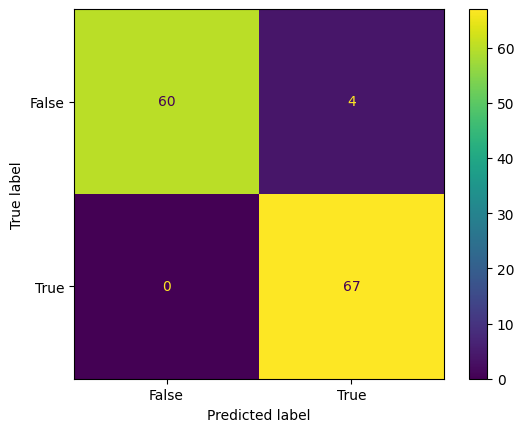

In [147]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use the best model from your last grid search
y_pred = grid_rbf.predict(x)
cm = confusion_matrix(y, y_pred)

ConfusionMatrixDisplay(cm, display_labels=['False', 'True']).plot()

In [129]:
from sklearn.cross_decomposition import PLSRegression

# PLS is a regressor, so we turn it into a classifier by rounding the output
# Or more simply, use a specialized PLS package if available,
# but for now, let's try a simpler 'Supervised' reduction:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

lda_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LDA()), # LDA finds the axis that BEST separates your two classes
    ('svc', SVC(kernel='linear'))
])

# LDA for 2 classes only has 1 component, so no grid needed for LDA itself
grid_lda = GridSearchCV(lda_pipe, {'svc__C': [0.01, 0.1, 1]}, cv=5)
grid_lda.fit(x, y)
print(f"LDA Score: {grid_lda.best_score_}")

LDA Score: 0.5797720797720798


In [138]:
pca_rbf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()), # Keep it low to prevent overfitting
    ('svc', SVC(kernel='rbf'))
])

param_grid_rbf = {
    'pca__n_components': [2, 5, 10, 15, 20, 30],
    'svc__C': [0.1, 1, 10, 100, 50],
    'svc__gamma': [0.001, 0.01,0.05, 0.1]
}

grid_rbf = GridSearchCV(pca_rbf_pipe, param_grid_rbf, cv=5)
grid_rbf.fit(x, y)

print(f"RBF + PCA Score: {grid_rbf.best_score_}")

RBF + PCA Score: 0.6481481481481481


In [139]:
print(f" {grid_rbf.best_params_}")

 {'pca__n_components': 15, 'svc__C': 100, 'svc__gamma': 0.001}


In [141]:
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('rf', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    'pca__n_components': [10, 15, 20, 30],
    'rf__n_estimators': [100, 200, 500], # Number of trees
    'rf__max_depth': [None, 5, 10, 20],   # Control overfitting
    'rf__min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(rf_pipe, param_grid_rf, cv=5)
grid_rf.fit(x, y)

print(f"Random Forest Best Score: {grid_rf.best_score_}")
print(f"Best Params: {grid_rf.best_params_}")

Random Forest Best Score: 0.6418803418803419
Best Params: {'pca__n_components': 15, 'rf__max_depth': None, 'rf__min_samples_split': 5, 'rf__n_estimators': 100}


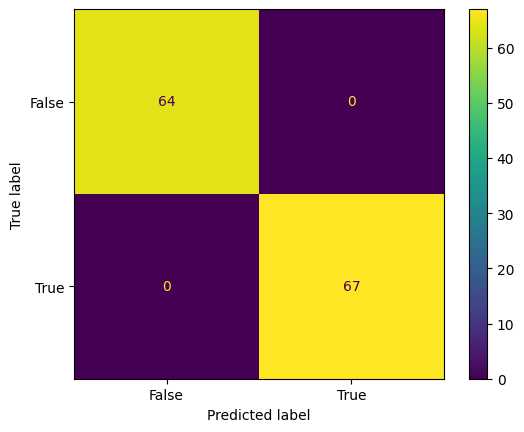

In [142]:
# Use the best model from your last grid search
y_pred = grid_rf.predict(x)
cm = confusion_matrix(y, y_pred)

ConfusionMatrixDisplay(cm, display_labels=['False', 'True']).plot()

In [144]:
from sklearn.model_selection import cross_val_predict

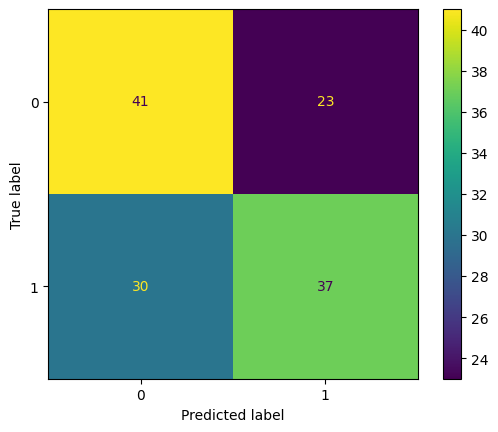

In [145]:
y_cv_pred = cross_val_predict(grid_rbf.best_estimator_, x, y, cv=5)

cm_cv = confusion_matrix(y, y_cv_pred)
ConfusionMatrixDisplay(cm_cv).plot()

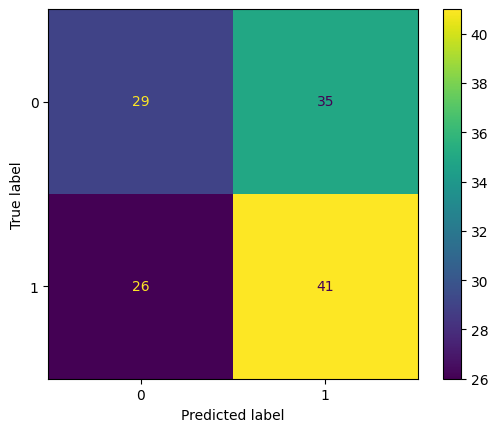

In [146]:
y_cv_pred = cross_val_predict(grid_rf.best_estimator_, x, y, cv=5)

cm_cv = confusion_matrix(y, y_cv_pred)
ConfusionMatrixDisplay(cm_cv).plot()

In [148]:
from sklearn.linear_model import LogisticRegression

# Using 'liblinear' solver because it works well with small datasets
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('lr', LogisticRegression(solver='liblinear', max_iter=1000))
])

param_grid_lr = {
    'pca__n_components': [10, 15, 20, 30],
    'lr__penalty': ['l1', 'l2'],        # L1 can actually zero-out useless components
    'lr__C': [0.01, 0.1, 1, 10, 100]    # Inverse of regularization strength
}

grid_lr = GridSearchCV(lr_pipe, param_grid_lr, cv=5)
grid_lr.fit(x, y)

print(f"Logistic Regression Best Score: {grid_lr.best_score_}")
print(f"Best Params: {grid_lr.best_params_}")

Logistic Regression Best Score: 0.5948717948717949
Best Params: {'lr__C': 10, 'lr__penalty': 'l1', 'pca__n_components': 30}
